# Imports

In [147]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math

# Exercises 1

## Exercises

File: "first data examples"

- What is the mean age of all persons in the data?
- What is the mean age of female persons? What about male persons?
- How many different types of educations are there?
- What are the different types of education and how many persons are the for each type?
- Is there a difference in educational level across sex?
- What is the most common relationship status?
- Is there a correlation between hours per week (worked) and age?
- Is the average hours per week (worked) different across different marital-status groups?
- Is there an income difference across sexes?

## Age and sex differences

In [148]:
adults = pd.read_csv("Data/adult.csv")

male_age = adults[adults["sex"] == "Male"]["age"]
mean_male_age = male_age.mean()

female_age = adults[adults["sex"] == "Female"]["age"]
mean_female_age = female_age.mean()

age_difference = [mean_male_age, mean_female_age, mean_male_age - mean_female_age]

age_difference

[np.float64(39.49439509954058),
 np.float64(36.92798913043478),
 np.float64(2.5664059691058014)]

## Amount of educations

In [149]:
educations = adults["education"].value_counts().reset_index()
educations.columns = ["education", "people_count"]
educations

,education,people_count
0,HS-grad,15784
1,Some-college,10878
2,Bachelors,8025
3,Masters,2657
4,Assoc-voc,2061
5,11th,1812
6,Assoc-acdm,1601
7,10th,1389
8,7th-8th,955
9,Prof-school,834


## Education level between sexes

In [150]:
male_education_levels = adults[adults["sex"] == "Male"]["education-num"]
mean_male_education_level = male_education_levels.mean()

female_education_levels = adults[adults["sex"] == "Female"]["education-num"]
mean_female_education_level = female_education_levels.mean()

[mean_male_education_level, mean_female_education_level, mean_male_education_level - mean_female_education_level]

[np.float64(10.094977029096478),
 np.float64(10.044034090909092),
 np.float64(0.05094293818738649)]

## People at different marital statuses

In [151]:
marital_statuses = adults["marital-status"].value_counts().reset_index()
marital_statuses.columns = ["marital-status", "people_count"]
marital_statuses

,marital-status,people_count
0,Married-civ-spouse,22379
1,Never-married,16117
2,Divorced,6633
3,Separated,1530
4,Widowed,1518
5,Married-spouse-absent,628
6,Married-AF-spouse,37


## Hours worked by age

<Axes: title={'center': 'Age vs Hours per Week Worked'}, xlabel='age'>

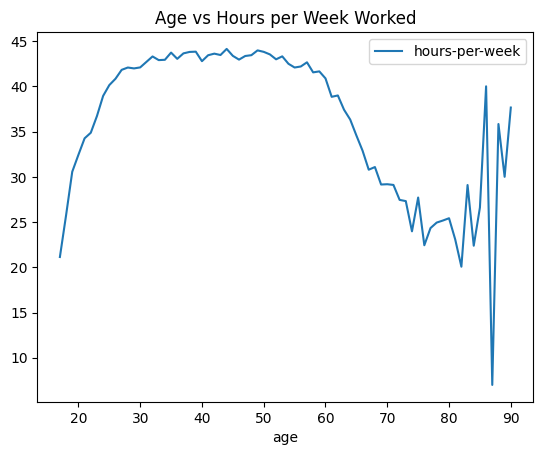

In [152]:
age_vs_work_hours = pd.DataFrame()

age_vs_work_hours["age"] = adults["age"]
age_vs_work_hours["hours-per-week"] = adults["hours-per-week"]

grouped_age_vs_work_hours = age_vs_work_hours.groupby("age").mean().reset_index()
grouped_age_vs_work_hours.plot(x="age", y="hours-per-week", kind="line", title="Age vs Hours per Week Worked")


## Hours worked by marital status 

<Axes: title={'center': 'Marital Status vs Average Hours per Week Worked'}, xlabel='marital-status'>

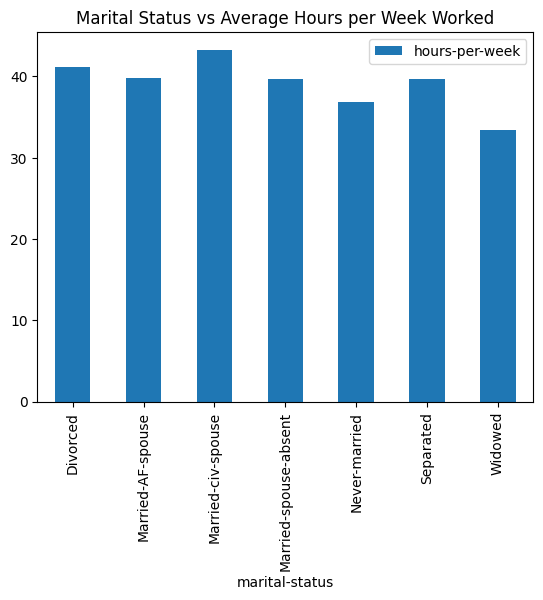

In [153]:
work_hours_by_marital_status = pd.DataFrame()

work_hours_by_marital_status["marital-status"] = adults["marital-status"]
work_hours_by_marital_status["hours-per-week"] = adults["hours-per-week"]

grouped_work_hours_by_marital_status = work_hours_by_marital_status.groupby("marital-status").mean().reset_index()
grouped_work_hours_by_marital_status.plot(x="marital-status", y="hours-per-week", kind="bar", title="Marital Status vs Average Hours per Week Worked")


## Income by sex

<Axes: title={'center': 'Sex vs Number of People Earning >50K'}, xlabel='sex'>

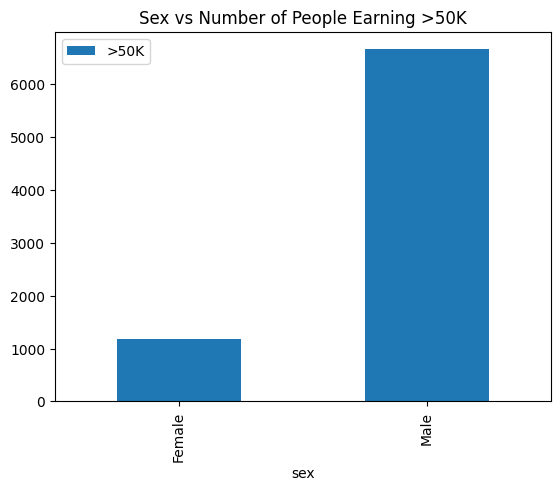

In [154]:
income_by_sex = pd.DataFrame()

income_by_sex["sex"] = adults["sex"]
income_by_sex["income"] = adults["income"]

grouped_income_by_sex = income_by_sex.groupby("sex").value_counts().unstack().reset_index()
grouped_income_by_sex.plot(x="sex", y=">50K", kind="bar", title="Sex vs Number of People Earning >50K")


# Exercise 2

## Exercises

File: "Exercises in DT and EDA"

- Plot the number of Cinemas in Danmark over the years. The next cell loads in the needed data for you if you have the file "DK_cinemas.csv" in the same folder as this notebook. 
- Based on the `Penguins` dataset, answer the following questions:
    - Make a barplot that shows how many penguins there are of each species in the dataset. Support the plot by calculating the numbers.
    - Make a barplot that shows the average body mass for each species of penguin. Support the plot by calculating the numbers
    - Make a boxplots that shows the distribution of the body mass for each species of penguin. Support the plot by calculating the numbers.
    - Make a scatterplot that shows the correlation between body mass (in g) and flipper length (in mm). Support the plot by calculating the numbers.
    - Use boxplots and histograms to show how bill length, bill depth, flipper length and body mass varies between species and sex.
    - Visualise how the linear correlation between body mass and flipper length varies between species and sex.
- Do an exploratory data analysis of the adult dataset. The cell below loads the dataset from UCI Machine Learning Repository into a pandas dataframe called `adult_data`. It requires that you have installed the package `ucimlrepo`. (Otherwise the dataset is on moodle page for this class.)
- Complete an exploratory data analysis of the titanic dataset (it is on moodle). (Remember, you can load it in as `titanic_data = pd.read_csv("titanic_survival_data.csv")`)
- Do an exploratory data analysis of the diabetes dataset. The cell below loads the dataset from the scikit learn package into the pandas dataframe called `diabetes_data`.


## 2.1

<Axes: title={'center': 'Cinemas in Denmark'}, xlabel='Year'>

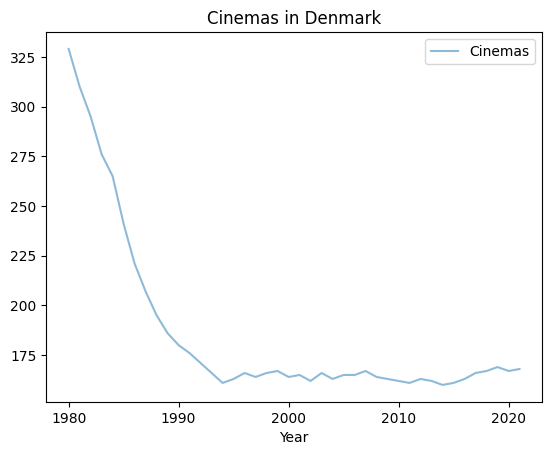

In [155]:
cinemas = pd.read_csv("Data/DK_cinemas.csv", sep=";")

cinemas.plot(x="Year", y="Cinemas", kind="line", title="Cinemas in Denmark", alpha=0.5)

## 2.2

In [156]:
penguins_data = sns.load_dataset("penguins")

penguins_data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


     species  count
0     Adelie    152
1     Gentoo    124
2  Chinstrap     68


<Axes: title={'center': 'Penguin Species Counts'}, xlabel='species'>

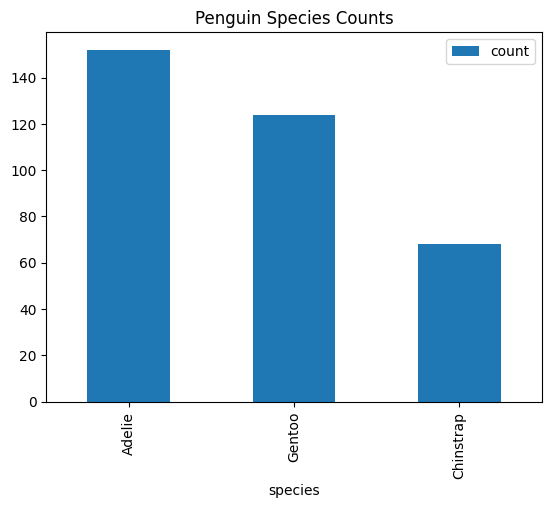

In [157]:
penguin_species = penguins_data["species"].unique()
penguin_species_counts = penguins_data["species"].value_counts().reset_index()

print(penguin_species_counts)
penguin_species_counts.plot(x="species", y="count", kind="bar", title="Penguin Species Counts")

     species  body_mass_g
0     Adelie  3700.662252
1  Chinstrap  3733.088235
2     Gentoo  5076.016260


<Axes: title={'center': 'Average Body Mass of Penguin Species'}, xlabel='species'>

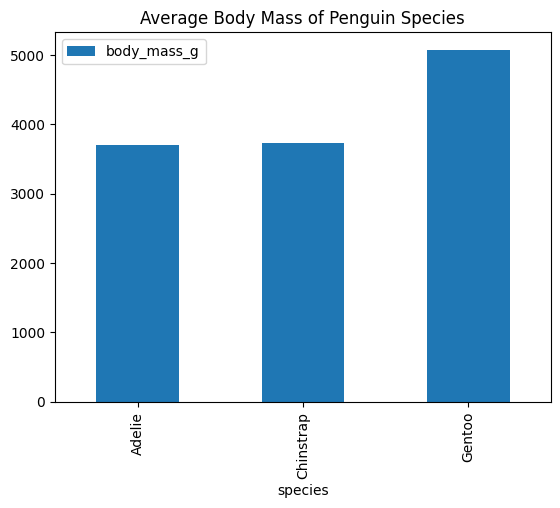

In [158]:
avg_species_bodymass = penguins_data.groupby("species")["body_mass_g"].mean().reset_index()

print(avg_species_bodymass)
avg_species_bodymass.plot(x="species", y="body_mass_g", kind="bar", title="Average Body Mass of Penguin Species")

Averages:
      species  body_mass_g
0     Adelie  3700.662252
1  Chinstrap  3733.088235
2     Gentoo  5076.016260
Medians:
      species  body_mass_g
0     Adelie       3700.0
1  Chinstrap       3700.0
2     Gentoo       5000.0
1st Quartiles:
      species  body_mass_g
0     Adelie       3350.0
1  Chinstrap       3487.5
2     Gentoo       4700.0
3rd Quartiles:
      species  body_mass_g
0     Adelie       4000.0
1  Chinstrap       3950.0
2     Gentoo       5500.0


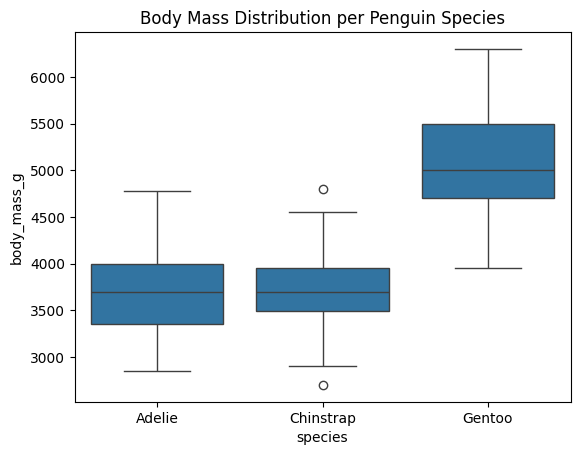

In [159]:
bodymass_distribution_per_species = penguins_data[["species", "body_mass_g"]]

bdps_averages = bodymass_distribution_per_species.groupby("species")["body_mass_g"].mean().reset_index()
bdps_medians = bodymass_distribution_per_species.groupby("species")["body_mass_g"].median().reset_index()
bdps_q1 = bodymass_distribution_per_species.groupby("species")["body_mass_g"].quantile(0.25).reset_index()
bdps_q3 = bodymass_distribution_per_species.groupby("species")["body_mass_g"].quantile(0.75).reset_index()
print("Averages:\n", bdps_averages)
print("Medians:\n", bdps_medians)
print("1st Quartiles:\n", bdps_q1)
print("3rd Quartiles:\n", bdps_q3)

sns.boxplot(x="species", y="body_mass_g", data=bodymass_distribution_per_species)
plt.title("Body Mass Distribution per Penguin Species")
plt.show()

Correlation between Body Mass and Flipper Length:
                    body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.839974
flipper_length_mm     0.839974           1.000000


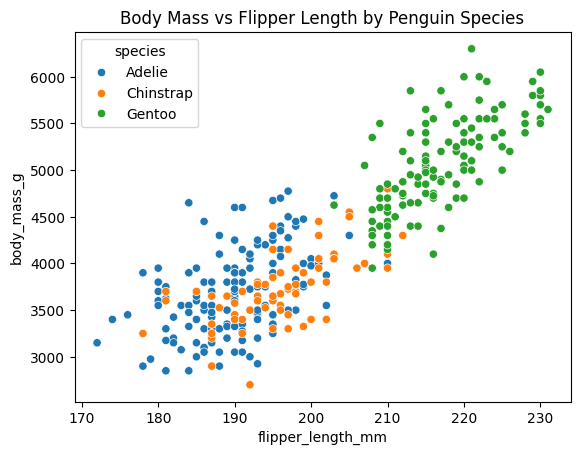

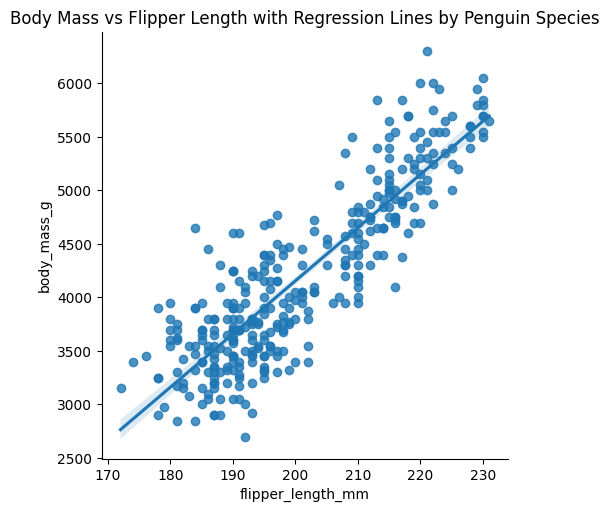

In [160]:
body_mass_to_flipper_length = penguins_data[["body_mass_g", "flipper_length_mm"]]

correlation = body_mass_to_flipper_length.corr('spearman')
print("Correlation between Body Mass and Flipper Length:\n", correlation)

# Fitted graph
sns.scatterplot(x="flipper_length_mm", y="body_mass_g", hue="species", data=body_mass_to_flipper_length.join(penguins_data["species"]))
plt.title("Body Mass vs Flipper Length by Penguin Species")
plt.show()

sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=body_mass_to_flipper_length.join(penguins_data["species"]))
plt.title("Body Mass vs Flipper Length with Regression Lines by Penguin Species")
plt.show()

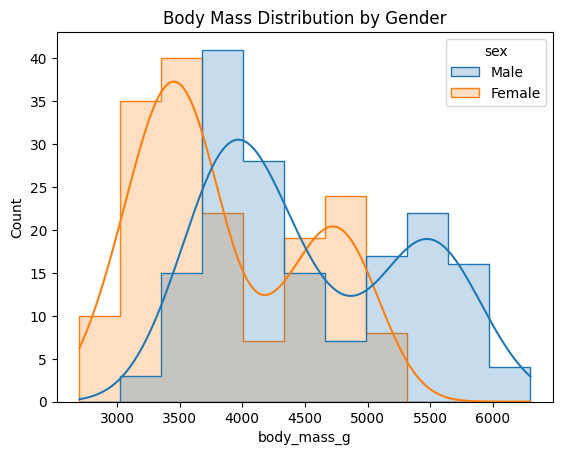

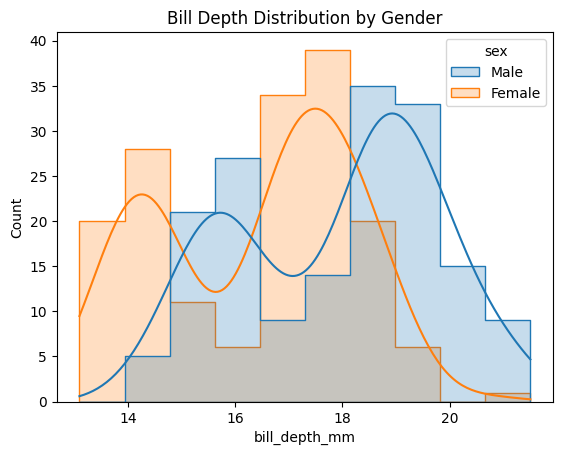

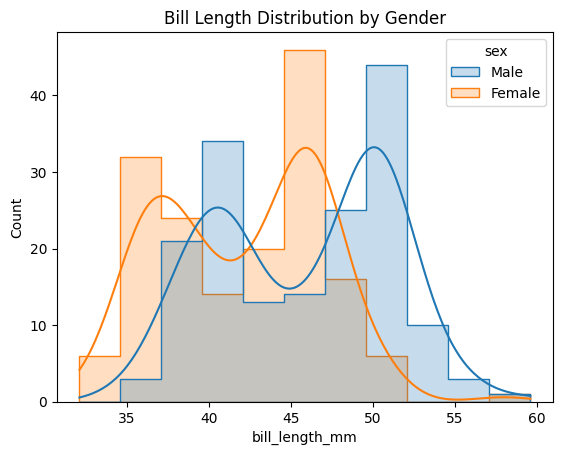

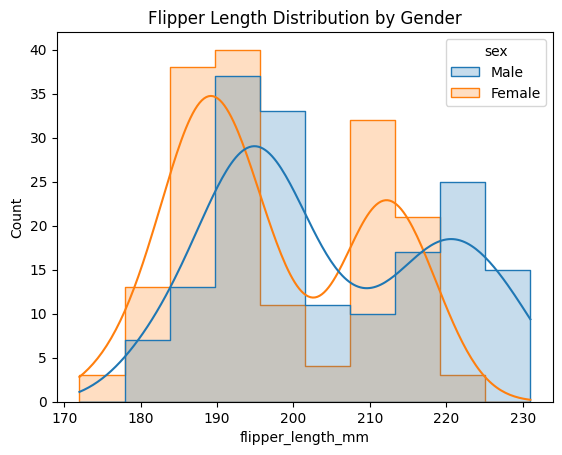

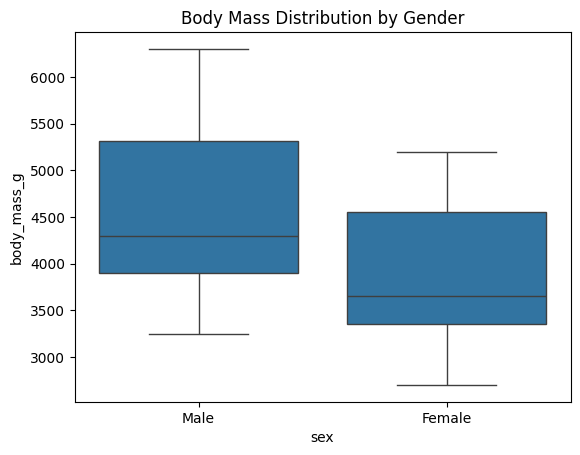

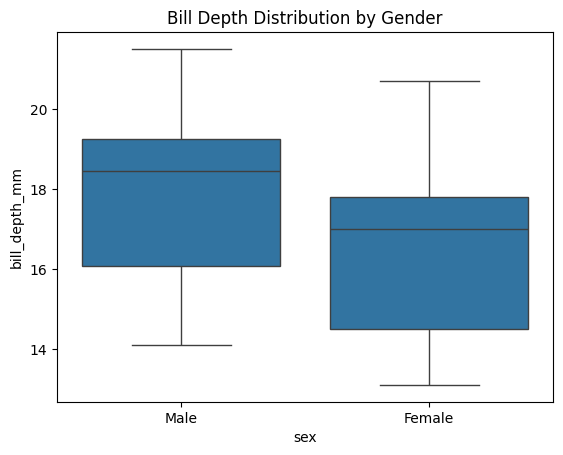

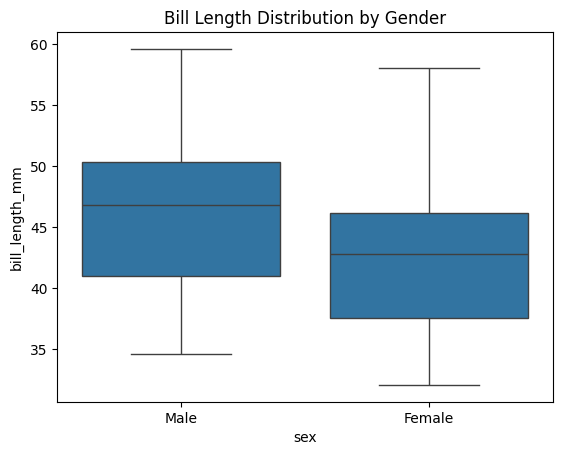

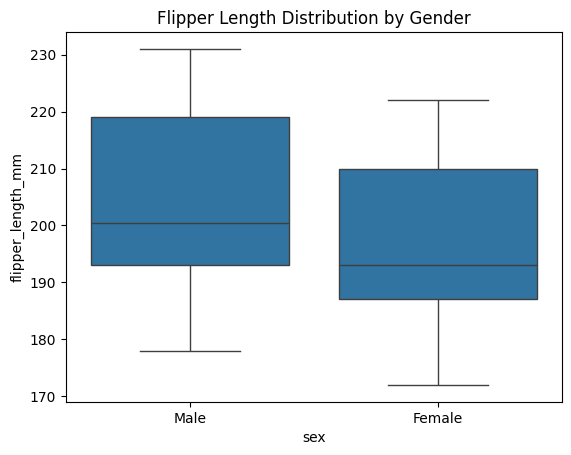

In [161]:
gender_to_bodymass = penguins_data[["sex", "body_mass_g"]]
gender_to_bill_depth = penguins_data[["sex", "bill_depth_mm"]]
gender_to_bill_length = penguins_data[["sex", "bill_length_mm"]]
gender_to_flipper_length = penguins_data[["sex", "flipper_length_mm"]]

# Histograms
sns.histplot(data=gender_to_bodymass, x="body_mass_g", hue="sex", kde=True, element="step")
plt.title("Body Mass Distribution by Gender")
plt.show() 

sns.histplot(data=gender_to_bill_depth, x="bill_depth_mm", hue="sex", kde=True, element="step")
plt.title("Bill Depth Distribution by Gender")
plt.show()

sns.histplot(data=gender_to_bill_length, x="bill_length_mm", hue="sex", kde=True, element="step")
plt.title("Bill Length Distribution by Gender")
plt.show()

sns.histplot(data=gender_to_flipper_length, x="flipper_length_mm", hue="sex", kde=True, element="step")
plt.title("Flipper Length Distribution by Gender")
plt.show()

# Boxplots
sns.boxplot(x="sex", y="body_mass_g", data=gender_to_bodymass)
plt.title("Body Mass Distribution by Gender")
plt.show()

sns.boxplot(x="sex", y="bill_depth_mm", data=gender_to_bill_depth)
plt.title("Bill Depth Distribution by Gender")
plt.show()

sns.boxplot(x="sex", y="bill_length_mm", data=gender_to_bill_length)
plt.title("Bill Length Distribution by Gender")
plt.show()

sns.boxplot(x="sex", y="flipper_length_mm", data=gender_to_flipper_length)
plt.title("Flipper Length Distribution by Gender")
plt.show()

Female Body Mass to Flipper Length Correlation:
                    body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.790429
flipper_length_mm     0.790429           1.000000
Male Body Mass to Flipper Length Correlation:
                    body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.796562
flipper_length_mm     0.796562           1.000000


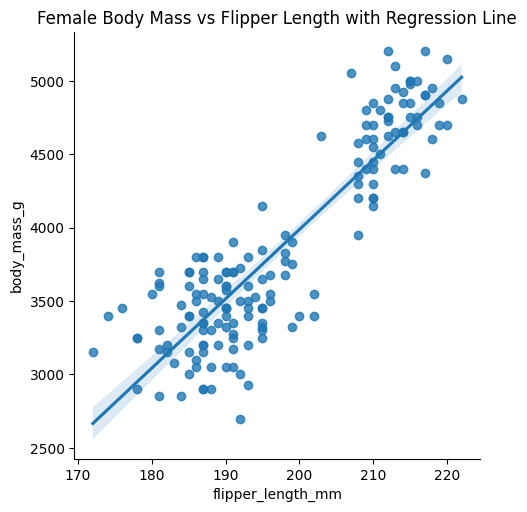

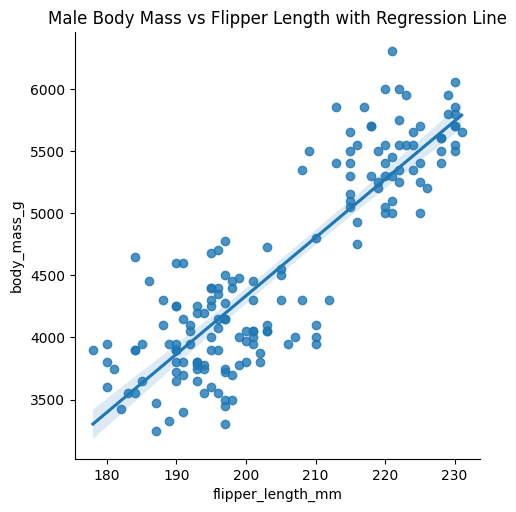

In [162]:
female_bodymass_to_flipper_length = penguins_data[penguins_data["sex"] == "Female"][["body_mass_g", "flipper_length_mm"]]
male_bodymass_to_flipper_length = penguins_data[penguins_data["sex"] == "Male"][["body_mass_g", "flipper_length_mm"]]

female_btfl_correlation = female_bodymass_to_flipper_length.corr('spearman')
male_btfl_correlation = male_bodymass_to_flipper_length.corr('spearman')

print("Female Body Mass to Flipper Length Correlation:\n", female_btfl_correlation)
print("Male Body Mass to Flipper Length Correlation:\n", male_btfl_correlation)

# Fitted graphs
sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=female_bodymass_to_flipper_length)
plt.title("Female Body Mass vs Flipper Length with Regression Line")
plt.show()

sns.lmplot(x="flipper_length_mm", y="body_mass_g", data=male_bodymass_to_flipper_length)
plt.title("Male Body Mass vs Flipper Length with Regression Line")
plt.show()

# Exercise 3

## 3.1

In this exercise we will use the penguins dataset (can be imported using the code `penguins_data = sns.load_dataset("penguins")`)

Please answer the following questions:
1. For the different species of penguins (Adelie, Chinstrap, and Gentoo), how many penguins are there of each species?
2. For the different species of penguins (Adelie, Chinstrap, and Gentoo), is the body mass variable normally distributed?
3. Test whether there is a difference in body mass for Adelie penguins and Chinstrap penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.
4. Test whether there is a difference in body mass for Chinstrap penguins and Gentoo penguins. Remember to justify your choice of test, clearly state the null hypothesis and alternative hypothesis, and state the significance level you will use. Hint: If your test give `nan` values you might need to drop missing values with the `dropna` method.

     species  count
0     Adelie    152
1     Gentoo    124
2  Chinstrap     68


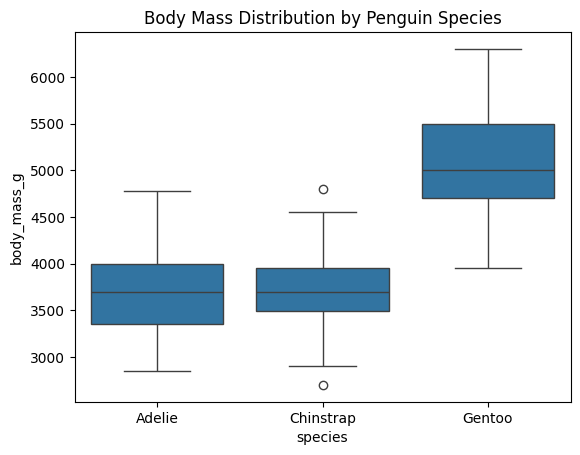

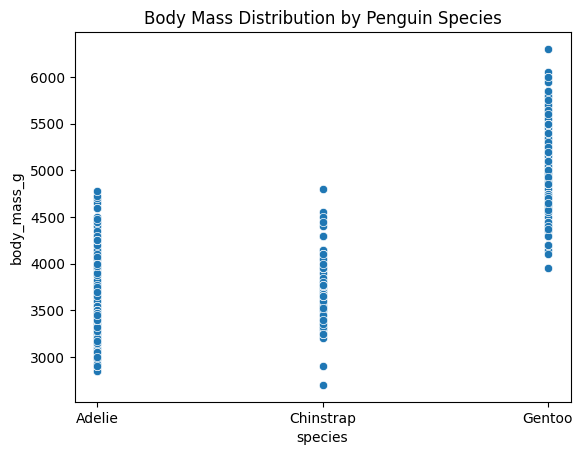

In [163]:
amount_penguins_per_species = penguins_data["species"].value_counts().reset_index()
amount_penguins_per_species.columns = ["species", "count"]
print(amount_penguins_per_species)

sns.boxplot(x="species", y="body_mass_g", data=penguins_data)
plt.title("Body Mass Distribution by Penguin Species")
plt.show()

# Scatterplot of body mass distribution by species
sns.scatterplot(x="species", y="body_mass_g", data=penguins_data)
plt.title("Body Mass Distribution by Penguin Species")
plt.show()

We assume that that both body-masses are normally distributed

In [164]:
adelie_penguins = penguins_data[penguins_data["species"] == "Adelie"]
chinstrap_penguins = penguins_data[penguins_data["species"] == "Chinstrap"]

statistic, p_value = stats.shapiro(adelie_penguins["body_mass_g"].dropna())
print("Shapiro-Wilk Test for Adelie Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

statistic, p_value = stats.shapiro(chinstrap_penguins["body_mass_g"].dropna())
print("Shapiro-Wilk Test for Chinstrap Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

# Seeing as the p-value for Adelie penguins is more than 0.05, we fail to reject the null hypothesis,l.

Shapiro-Wilk Test for Adelie Penguins Body Mass:
T-statistic: 0.9807078507062791
P-value: 0.03239702501305105
Shapiro-Wilk Test for Chinstrap Penguins Body Mass:
T-statistic: 0.984493761674102
P-value: 0.5605082387697975


We see that Chinstrap penguins are likely normally distributed, but Adelie are not. Thus we use a Mann-Whitney U test.

H₀: There is no difference in body mass between Adelie and Chinstrap penguins
    (μ_Adelie = μ_Chinstrap)

H₁: There is a difference in body mass between Adelie and Chinstrap penguins
    (μ_Adelie ≠ μ_Chinstrap)

α = 0.05

In [165]:
u_statistic, p_value_u = stats.mannwhitneyu(adelie_penguins["body_mass_g"].dropna(), chinstrap_penguins["body_mass_g"].dropna())
print("Mann-Whitney U Test between Adelie and Chinstrap Penguins Body Mass:")
print("U-statistic:", u_statistic)
print("P-value:", p_value_u)


Mann-Whitney U Test between Adelie and Chinstrap Penguins Body Mass:
U-statistic: 4831.0
P-value: 0.4854772721011861


From the result we see that there is no difference in boy mass between the two penguin species.

Comparing Chinstrap and Gentoo we again assume the two sets are normally distributed, knowing that Chinstrap is, we test for Gentoo.

In [166]:
gentoo_penguins = penguins_data[penguins_data["species"] == "Gentoo"]

statistic, p_value = stats.shapiro(gentoo_penguins["body_mass_g"].dropna())
print("Shapiro-Wilk Test for Gentoo Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)



Shapiro-Wilk Test for Gentoo Penguins Body Mass:
T-statistic: 0.9859276066609362
P-value: 0.23361648888961845


With a p-value well above 0.05, gentoo penguins are likely normally distributed, so we use a t-test.

H₀: There is no difference in body mass between Gentoo and Chinstrap penguins
    (μ_Gentoo = μ_Chinstrap)

H₁: There is a difference in body mass between Gentoo and Chinstrap penguins
    (μ_Gentoo ≠ μ_Chinstrap)

α = 0.05

In [167]:
statistic, p_value = stats.ttest_ind(gentoo_penguins["body_mass_g"].dropna(), chinstrap_penguins["body_mass_g"].dropna())
print("T-Test between Gentoo and Chinstrap Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", round(p_value, 50))


T-Test between Gentoo and Chinstrap Penguins Body Mass:
T-statistic: 19.103227243520955
P-value: 5.2661999999999995e-46


Seeing as the the p-value of our t-test is very well below 0.05, it would strongly suggest that there is a difference in the bodymass of Gentoo and Chinstrap penguins, thus rejecting the null hyphothesis.

## 3.2

Load in the "fb_like_and_share.csv" data and answer the following questions:

1. Is there a difference in the distribution of likes for photos and videos? Justify your choice of test(s).
2. Is there a difference in the distribution of share counts for photos and videos? Justify your choice of test(s).
3. Perform an ANOVA test to test if there is a difference in means across type of posts for shares. Does it make sense to perform this ANOVA test?
4. Is there actually a statistical significant difference in the distribution of share counts for any two groups?

In [168]:
fb_like_and_share = pd.read_csv("Data/fb_like_and_share.csv", sep=";")
fb_like_and_share.head()

,type,likes_count_fb,shares_count_fb
0,video,577,7
1,photo,2802,23
2,video,490,14
3,link,535,16
4,photo,1049,44


In [169]:
fb_photos = fb_like_and_share[fb_like_and_share["type"] == "photo"]
fb_videos = fb_like_and_share[fb_like_and_share["type"] == "video"]

print("Facebook Photos Data:")
print(fb_photos)
print("Facebook Videos Data:")
print(fb_videos)

Facebook Photos Data:
     type  likes_count_fb  shares_count_fb
1   photo            2802               23
4   photo            1049               44
5   photo            1557               85
6   photo             838                1
8   photo             100                1
10  photo            1258               19
11  photo             487                5
12  photo             184               12
14  photo             653               43
19  photo             637                3
26  photo            1544               47
27  photo             320                0
28  photo             329                3
Facebook Videos Data:
     type  likes_count_fb  shares_count_fb
0   video             577                7
2   video             490               14
9   video             112                3
13  video            1051               78
17  video              35                0
20  video             116                1
22  video             175                0
30  video 

We begin by assuming both sets are normally distributed, with an α = 0.05

In [170]:
statistic, p_value = stats.shapiro(fb_photos["likes_count_fb"].dropna())
print("Shapiro-Wilk Test for Facebook Photos Like Count:")
print("T-statistic:", statistic)
print("P-value:", p_value) 

statistic, p_value = stats.shapiro(fb_videos["likes_count_fb"].dropna())
print("Shapiro-Wilk Test for Facebook Videos Like Count:")
print("T-statistic:", statistic)
print("P-value:", p_value)

Shapiro-Wilk Test for Facebook Photos Like Count:
T-statistic: 0.8774655646725982
P-value: 0.06589939260226885
Shapiro-Wilk Test for Facebook Videos Like Count:
T-statistic: 0.8477493538641958
P-value: 0.07038250110283344


Seeing values above 0.05 for both data sets, we can see that the data is normally distributed with some deviation. This does not reject our null hypothesis, so we can use a t-test to check for differences in like counts between sets with the following hypothesis:

H₀: There is no difference between like counts 
    (μ_Photos = μ_Videos)

H₁: There is a difference between like counts 
    (μ_Photos ≠ μ_Videos)

α = 0.05

In [171]:
statistics, p_value = stats.ttest_ind(fb_photos["likes_count_fb"].dropna(), fb_videos["likes_count_fb"].dropna())

print("T-Test between Facebook Photos and Videos Like Count:")
print("T-statistic:", statistics)
print("P-value:", p_value)


T-Test between Facebook Photos and Videos Like Count:
T-statistic: 2.125454058083514
P-value: 0.04619850270741723


Looking at the p-value of our test, we have a value of 0.046, which is below the significance level, rejecting our null hyphothesis as there's a somewhat strong indication of a difference in like counts between the two sets.